# 🎓 Experimentos com Learned Wavelet (LearnedWaveletDWT1D_QMF)

## Objetivo
Avaliar o impacto de usar wavelets aprendidas (end-to-end) vs wavelets fixas:
- **LearnedWavelet + CNN**
- **LearnedWavelet + LSTM**
- **LearnedWavelet + CNN-LSTM**
- **LearnedWavelet + Transformer**

## Hipótese
Wavelets aprendidas podem adaptar-se às características específicas do sinal,
potencialmente superando wavelets fixas como db2.

## Arquitetura
```
Input (raw signal) -> LearnedWaveletDWT1D_QMF -> [CNN/LSTM/CNN-LSTM/Transformer] -> Output
```

A camada LearnedWaveletDWT1D_QMF aprende os filtros low/high pass durante o treinamento.
Grid search sobre dropout, regularização e tamanho de arquitetura.

In [1]:
# ── GPU selection (must come BEFORE importing TensorFlow) ──
import os, sys
sys.path.append('.')
sys.path.append('../../models')
from config.experiment_config import (
    DATA_DIR, RESULTS_DIR, MODELS_DIR,
    DL_TRAINING_CONFIG, LEARNED_WAVELET_CONFIG,
    LEARNED_WAVELET_MODELS_CONFIG,
    generate_learned_wavelet_grid, SEED,
    GPU_ID, EPOCHS_OVERRIDE, MAX_GRID_CONFIGS,
)
# (CUDA_VISIBLE_DEVICES já foi configurado pelo experiment_config)

# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
import random
import warnings
warnings.filterwarnings('ignore')

# TensorFlow (importado APÓS seleção de GPU)
import tensorflow as tf
print(f"TensorFlow version: {tf.__version__}")
print(f"GPU disponível: {tf.config.list_physical_devices('GPU')}")

# Imports locais - modelos LWT
from LWT import LearnedWaveletDWT1D_QMF, LearnedWaveletPair1D_QMF

from src.models import (
    create_learned_wavelet_cnn_model,
    create_learned_wavelet_lstm_model,
    create_learned_wavelet_cnn_lstm_model,
    create_learned_wavelet_transformer_model,
    get_callbacks, get_distribute_strategy,
)
from src.evaluation import RegressionEvaluator, ResultsManager
from src.visualization import ExperimentVisualizer

# ── Reprodutibilidade: fixar seed global ──
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)

# Multi-GPU strategy
strategy = get_distribute_strategy()

# Configuração
plt.style.use('seaborn-v0_8-whitegrid')
(RESULTS_DIR / "learned_wavelet_experiments").mkdir(parents=True, exist_ok=True)

print(f"\n✅ Imports realizados com sucesso!")
print(f"📦 LearnedWaveletDWT1D_QMF carregado")
print(f"🎲 SEED={SEED} definido para numpy, tf e random")
if GPU_ID:
    print(f"🖥️  GPU selecionada: {GPU_ID}")
if EPOCHS_OVERRIDE:
    print(f"⚡ EPOCHS_OVERRIDE={EPOCHS_OVERRIDE}")
if MAX_GRID_CONFIGS:
    print(f"⚡ MAX_GRID_CONFIGS={MAX_GRID_CONFIGS}")

2026-03-07 19:41:27.470579: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


TensorFlow version: 2.20.0
GPU disponível: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


⚡ OneDeviceStrategy: GPU:0

✅ Imports realizados com sucesso!
📦 LearnedWaveletDWT1D_QMF carregado
🎲 SEED=42 definido para numpy, tf e random
🖥️  GPU selecionada: 0


I0000 00:00:1772923290.278385  830854 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 14163 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4080 SUPER, pci bus id: 0000:01:00.0, compute capability: 8.9


## 1. Carregar Dados

In [2]:
# Carregar datasets (raw)
X_train = np.load(DATA_DIR / "X_train.npy")
y_train = np.load(DATA_DIR / "y_train.npy")
X_val = np.load(DATA_DIR / "X_val.npy")
y_val = np.load(DATA_DIR / "y_val.npy")
X_test = np.load(DATA_DIR / "X_test.npy")
y_test = np.load(DATA_DIR / "y_test.npy")

# Adicionar dimensão de canal
X_train = X_train[..., np.newaxis]
X_val = X_val[..., np.newaxis]
X_test = X_test[..., np.newaxis]

print(f"📦 Dados Carregados (Raw + Canal):")
print(f"  Train: {X_train.shape}")
print(f"  Val:   {X_val.shape}")
print(f"  Test:  {X_test.shape}")

input_shape = X_train.shape[1:]
print(f"\nInput shape: {input_shape}")

📦 Dados Carregados (Raw + Canal):
  Train: (34820, 256, 1)
  Val:   (7462, 256, 1)
  Test:  (7462, 256, 1)

Input shape: (256, 1)


## 2. Configuração das Learned Wavelets

In [3]:
# Configuração da wavelet aprendida
wavelet_config = LEARNED_WAVELET_CONFIG.copy()

print("Configuração LearnedWaveletDWT1D_QMF:")
for k, v in wavelet_config.items():
    print(f"  {k}: {v}")

# Gerenciadores
results_manager = ResultsManager(RESULTS_DIR / "learned_wavelet_experiments")
evaluator = RegressionEvaluator()
visualizer = ExperimentVisualizer()

training_config = DL_TRAINING_CONFIG.copy()

# Armazenar resultados
all_results = {}          # melhor de cada arquitetura
all_histories = {}        # histórico do melhor
all_grid_results = []     # TODOS os resultados do grid
best_models = {}          # melhor modelo Keras de cada arquitetura (para filtros)

Configuração LearnedWaveletDWT1D_QMF:
  levels: 2
  kernel_size: 32
  wavelet_net_units: 32
  reg_energy: 0.01
  reg_high_dc: 0.01
  reg_smooth: 0.001
  normalize_low: sum1


## 3. Definição dos Modelos (via src/models.py + config centralizado)

Modelos criados pelo factory em `src/models.py`:
- `create_learned_wavelet_cnn_model`
- `create_learned_wavelet_lstm_model`
- `create_learned_wavelet_cnn_lstm_model` (NOVO)
- `create_learned_wavelet_transformer_model`

Parâmetros base em `LEARNED_WAVELET_MODELS_CONFIG` e grid em `LEARNED_WAVELET_GRID_AXES`.

In [4]:
# Mapear nome da arquitetura → factory function
MODEL_BUILDERS = {
    'CNN': create_learned_wavelet_cnn_model,
    'LSTM': create_learned_wavelet_lstm_model,
    'CNN_LSTM': create_learned_wavelet_cnn_lstm_model,
    'Transformer': create_learned_wavelet_transformer_model,
}

print("✅ Factory functions mapeadas:")
for name in MODEL_BUILDERS:
    base_cfg = LEARNED_WAVELET_MODELS_CONFIG.get(name, {})
    grid_size = len(generate_learned_wavelet_grid(name))
    print(f"  {name}: {grid_size} combinações no grid")

✅ Factory functions mapeadas:
  CNN: 18 combinações no grid
  LSTM: 18 combinações no grid
  CNN_LSTM: 36 combinações no grid
  Transformer: 48 combinações no grid


## 4. Experimento 1: LearnedWavelet + CNN (Grid)

In [5]:
print("="*70)
print("🎓 Grid Search: LearnedWavelet + CNN")
print("="*70)

arch = 'CNN'
grid = generate_learned_wavelet_grid(arch)
base_params = LEARNED_WAVELET_MODELS_CONFIG[arch].copy()
best_rmse, best_key = float('inf'), None

for gi, variation in enumerate(grid):
    params = {**base_params, **variation}
    run_name = f"LearnedWavelet_CNN_g{gi}"
    print(f"\n--- [{gi+1}/{len(grid)}] {run_name}: {variation}")

    tf.keras.backend.clear_session()
    with strategy.scope():
        model = MODEL_BUILDERS[arch](input_shape, wavelet_config=wavelet_config, cnn_params=params)

    model_path = str(MODELS_DIR / f"learned_wavelet_cnn_g{gi}.keras")
    callbacks = get_callbacks(
        model_path,
        patience_early=training_config['early_stopping_patience'],
        patience_lr=training_config['reduce_lr_patience'],
        min_lr=training_config['min_lr'],
    )

    t0 = time.time()
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=training_config['epochs'],
        batch_size=training_config['batch_size'],
        callbacks=callbacks, verbose=0,
    )
    elapsed = time.time() - t0

    y_pred = model.predict(X_test, verbose=0).flatten()
    metrics = evaluator.evaluate(y_test, y_pred)

    print(f"    RMSE={metrics['rmse']:.6f}  MAE={metrics['mae']:.6f}  "
          f"R²={metrics['r2']:.6f}  Time={elapsed:.1f}s")

    row = {'Model': 'LearnedWavelet_CNN', 'grid_idx': gi, **variation,
           'RMSE': metrics['rmse'], 'MAE': metrics['mae'],
           'R²': metrics['r2'], 'Params': model.count_params(),
           'Time (s)': elapsed, 'Epochs': len(history.history['loss'])}
    all_grid_results.append(row)

    if metrics['rmse'] < best_rmse:
        best_rmse = metrics['rmse']
        best_key = run_name
        all_results['LearnedWavelet_CNN'] = {
            'metrics': metrics, 'time': elapsed,
            'epochs': len(history.history['loss']),
            'y_pred': y_pred, 'params': model.count_params(),
            'best_variation': variation,
        }
        all_histories['LearnedWavelet_CNN'] = history.history
        best_models['LearnedWavelet_CNN'] = model
        model.save(str(MODELS_DIR / "learned_wavelet_cnn_best.keras"))

    results_manager.log_experiment('DL_LearnedWavelet', run_name, metrics,
                                   {'params': params, 'wavelet_config': wavelet_config})

print(f"\n🏆 Melhor CNN: {best_key} — RMSE={best_rmse:.6f}")

🎓 Grid Search: LearnedWavelet + CNN

--- [1/18] LearnedWavelet_CNN_g0: {'dropout_rate': 0.2, 'l2_reg': 0.0001, 'filters': [32, 64, 128]}


2026-03-07 19:41:34.645837: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91900


2026-03-07 19:41:42.760767: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node MultiDeviceIteratorGetNextFromShard}}]]
2026-03-07 19:41:42.760844: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node MultiDeviceIteratorGetNextFromShard}}]]
	 [[RemoteCall]]


2026-03-07 19:41:44.038860: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node MultiDeviceIteratorGetNextFromShard}}]]
	 [[RemoteCall]]


2026-03-07 19:41:51.557034: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node MultiDeviceIteratorGetNextFromShard}}]]
	 [[RemoteCall]]


...


Epoch 55: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.



Epoch 62: ReduceLROnPlateau reducing learning rate to 6.25000029685907e-05.


Epoch 63: early stopping


Restoring model weights from the end of the best epoch: 48.


    RMSE=0.257962  MAE=0.201352  R²=0.934152  Time=468.3s

🏆 Melhor CNN: LearnedWavelet_CNN_g9 — RMSE=0.249843


## 5. Experimento 2: LearnedWavelet + LSTM (Grid)

In [6]:
print("="*70)
print("🎓 Grid Search: LearnedWavelet + LSTM")
print("="*70)

arch = 'LSTM'
grid = generate_learned_wavelet_grid(arch)
base_params = LEARNED_WAVELET_MODELS_CONFIG[arch].copy()
best_rmse, best_key = float('inf'), None

for gi, variation in enumerate(grid):
    params = {**base_params, **variation}
    run_name = f"LearnedWavelet_LSTM_g{gi}"
    print(f"\n--- [{gi+1}/{len(grid)}] {run_name}: {variation}")

    tf.keras.backend.clear_session()
    with strategy.scope():
        model = MODEL_BUILDERS[arch](input_shape, wavelet_config=wavelet_config, lstm_params=params)

    model_path = str(MODELS_DIR / f"learned_wavelet_lstm_g{gi}.keras")
    callbacks = get_callbacks(
        model_path,
        patience_early=training_config['early_stopping_patience'],
        patience_lr=training_config['reduce_lr_patience'],
        min_lr=training_config['min_lr'],
    )

    t0 = time.time()
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=training_config['epochs'],
        batch_size=training_config['batch_size'],
        callbacks=callbacks, verbose=0,
    )
    elapsed = time.time() - t0

    y_pred = model.predict(X_test, verbose=0).flatten()
    metrics = evaluator.evaluate(y_test, y_pred)

    print(f"    RMSE={metrics['rmse']:.6f}  MAE={metrics['mae']:.6f}  "
          f"R²={metrics['r2']:.6f}  Time={elapsed:.1f}s")

    row = {'Model': 'LearnedWavelet_LSTM', 'grid_idx': gi, **variation,
           'RMSE': metrics['rmse'], 'MAE': metrics['mae'],
           'R²': metrics['r2'], 'Params': model.count_params(),
           'Time (s)': elapsed, 'Epochs': len(history.history['loss'])}
    all_grid_results.append(row)

    if metrics['rmse'] < best_rmse:
        best_rmse = metrics['rmse']
        best_key = run_name
        all_results['LearnedWavelet_LSTM'] = {
            'metrics': metrics, 'time': elapsed,
            'epochs': len(history.history['loss']),
            'y_pred': y_pred, 'params': model.count_params(),
            'best_variation': variation,
        }
        all_histories['LearnedWavelet_LSTM'] = history.history
        best_models['LearnedWavelet_LSTM'] = model
        model.save(str(MODELS_DIR / "learned_wavelet_lstm_best.keras"))

    results_manager.log_experiment('DL_LearnedWavelet', run_name, metrics,
                                   {'params': params, 'wavelet_config': wavelet_config})

print(f"\n🏆 Melhor LSTM: {best_key} — RMSE={best_rmse:.6f}")

🎓 Grid Search: LearnedWavelet + LSTM

--- [1/18] LearnedWavelet_LSTM_g0: {'dropout_rate': 0.2, 'l2_reg': 0.0001, 'units': [64, 32]}



Epoch 17: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.


2026-03-07 21:51:20.074741: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node MultiDeviceIteratorGetNextFromShard}}]]
	 [[RemoteCall]]



Epoch 41: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.



Epoch 48: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.


...


Epoch 57: ReduceLROnPlateau reducing learning rate to 6.25000029685907e-05.



Epoch 64: ReduceLROnPlateau reducing learning rate to 3.125000148429535e-05.


Epoch 65: early stopping


Restoring model weights from the end of the best epoch: 50.


    RMSE=0.334774  MAE=0.250872  R²=0.889100  Time=744.6s

🏆 Melhor LSTM: LearnedWavelet_LSTM_g0 — RMSE=0.299695


## 6. Experimento 3: LearnedWavelet + CNN-LSTM (Grid) — NOVO

In [7]:
print("="*70)
print("🎓 Grid Search: LearnedWavelet + CNN-LSTM")
print("="*70)

arch = 'CNN_LSTM'
grid = generate_learned_wavelet_grid(arch)
base_params = LEARNED_WAVELET_MODELS_CONFIG[arch].copy()
best_rmse, best_key = float('inf'), None

for gi, variation in enumerate(grid):
    params = {**base_params, **variation}
    run_name = f"LearnedWavelet_CNN_LSTM_g{gi}"
    print(f"\n--- [{gi+1}/{len(grid)}] {run_name}: {variation}")

    tf.keras.backend.clear_session()
    with strategy.scope():
        model = MODEL_BUILDERS[arch](input_shape, wavelet_config=wavelet_config, cnn_lstm_params=params)

    model_path = str(MODELS_DIR / f"learned_wavelet_cnn_lstm_g{gi}.keras")
    callbacks = get_callbacks(
        model_path,
        patience_early=training_config['early_stopping_patience'],
        patience_lr=training_config['reduce_lr_patience'],
        min_lr=training_config['min_lr'],
    )

    t0 = time.time()
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=training_config['epochs'],
        batch_size=training_config['batch_size'],
        callbacks=callbacks, verbose=0,
    )
    elapsed = time.time() - t0

    y_pred = model.predict(X_test, verbose=0).flatten()
    metrics = evaluator.evaluate(y_test, y_pred)

    print(f"    RMSE={metrics['rmse']:.6f}  MAE={metrics['mae']:.6f}  "
          f"R²={metrics['r2']:.6f}  Time={elapsed:.1f}s")

    row = {'Model': 'LearnedWavelet_CNN_LSTM', 'grid_idx': gi, **variation,
           'RMSE': metrics['rmse'], 'MAE': metrics['mae'],
           'R²': metrics['r2'], 'Params': model.count_params(),
           'Time (s)': elapsed, 'Epochs': len(history.history['loss'])}
    all_grid_results.append(row)

    if metrics['rmse'] < best_rmse:
        best_rmse = metrics['rmse']
        best_key = run_name
        all_results['LearnedWavelet_CNN_LSTM'] = {
            'metrics': metrics, 'time': elapsed,
            'epochs': len(history.history['loss']),
            'y_pred': y_pred, 'params': model.count_params(),
            'best_variation': variation,
        }
        all_histories['LearnedWavelet_CNN_LSTM'] = history.history
        best_models['LearnedWavelet_CNN_LSTM'] = model
        model.save(str(MODELS_DIR / "learned_wavelet_cnn_lstm_best.keras"))

    results_manager.log_experiment('DL_LearnedWavelet', run_name, metrics,
                                   {'params': params, 'wavelet_config': wavelet_config})

print(f"\n🏆 Melhor CNN-LSTM: {best_key} — RMSE={best_rmse:.6f}")

🎓 Grid Search: LearnedWavelet + CNN-LSTM

--- [1/36] LearnedWavelet_CNN_LSTM_g0: {'dropout_rate': 0.2, 'l2_reg': 0.0001, 'cnn_filters': [32, 64], 'lstm_units': [64, 32]}



Epoch 19: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.



Epoch 33: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.



Epoch 40: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.


Epoch 41: early stopping


...


Epoch 66: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.



Epoch 80: ReduceLROnPlateau reducing learning rate to 6.25000029685907e-05.



Epoch 89: ReduceLROnPlateau reducing learning rate to 3.125000148429535e-05.


Restoring model weights from the end of the best epoch: 96.


    RMSE=0.329949  MAE=0.255396  R²=0.892274  Time=953.3s

🏆 Melhor CNN-LSTM: LearnedWavelet_CNN_LSTM_g19 — RMSE=0.255277


## 7. Experimento 4: LearnedWavelet + Transformer (Grid)

In [8]:
print("="*70)
print("🎓 Grid Search: LearnedWavelet + Transformer")
print("="*70)

arch = 'Transformer'
grid = generate_learned_wavelet_grid(arch)
base_params = LEARNED_WAVELET_MODELS_CONFIG[arch].copy()
best_rmse, best_key = float('inf'), None

for gi, variation in enumerate(grid):
    params = {**base_params, **variation}
    run_name = f"LearnedWavelet_Transformer_g{gi}"
    print(f"\n--- [{gi+1}/{len(grid)}] {run_name}: {variation}")

    tf.keras.backend.clear_session()
    with strategy.scope():
        model = MODEL_BUILDERS[arch](input_shape, wavelet_config=wavelet_config, transformer_params=params)

    model_path = str(MODELS_DIR / f"learned_wavelet_transformer_g{gi}.keras")
    callbacks = get_callbacks(
        model_path,
        patience_early=training_config['early_stopping_patience'],
        patience_lr=training_config['reduce_lr_patience'],
        min_lr=training_config['min_lr'],
        use_reduce_lr=not params.get('use_warmup', True),
    )

    t0 = time.time()
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=training_config['epochs'],
        batch_size=training_config['batch_size'],
        callbacks=callbacks, verbose=0,
    )
    elapsed = time.time() - t0

    y_pred = model.predict(X_test, verbose=0).flatten()
    metrics = evaluator.evaluate(y_test, y_pred)

    print(f"    RMSE={metrics['rmse']:.6f}  MAE={metrics['mae']:.6f}  "
          f"R²={metrics['r2']:.6f}  Time={elapsed:.1f}s")

    row = {'Model': 'LearnedWavelet_Transformer', 'grid_idx': gi, **variation,
           'RMSE': metrics['rmse'], 'MAE': metrics['mae'],
           'R²': metrics['r2'], 'Params': model.count_params(),
           'Time (s)': elapsed, 'Epochs': len(history.history['loss'])}
    all_grid_results.append(row)

    if metrics['rmse'] < best_rmse:
        best_rmse = metrics['rmse']
        best_key = run_name
        all_results['LearnedWavelet_Transformer'] = {
            'metrics': metrics, 'time': elapsed,
            'epochs': len(history.history['loss']),
            'y_pred': y_pred, 'params': model.count_params(),
            'best_variation': variation,
        }
        all_histories['LearnedWavelet_Transformer'] = history.history
        best_models['LearnedWavelet_Transformer'] = model
        model.save(str(MODELS_DIR / "learned_wavelet_transformer_best.keras"))

    results_manager.log_experiment('DL_LearnedWavelet', run_name, metrics,
                                   {'params': params, 'wavelet_config': wavelet_config})

print(f"\n🏆 Melhor Transformer: {best_key} — RMSE={best_rmse:.6f}")

🎓 Grid Search: LearnedWavelet + Transformer

--- [1/48] LearnedWavelet_Transformer_g0: {'dropout_rate': 0.15, 'num_heads': 2, 'ff_dim': 64, 'num_transformer_blocks': 2, 'l2_reg': 0.0001}


Epoch 44: early stopping


Restoring model weights from the end of the best epoch: 29.


    RMSE=0.264514  MAE=0.201621  R²=0.930765  Time=454.8s

--- [2/48] LearnedWavelet_Transformer_g1: {'dropout_rate': 0.15, 'num_heads': 2, 'ff_dim': 64, 'num_transformer_blocks': 2, 'l2_reg': 0.001}


Epoch 52: early stopping


...

Restoring model weights from the end of the best epoch: 14.


    RMSE=0.368992  MAE=0.279892  R²=0.865271  Time=368.2s

--- [48/48] LearnedWavelet_Transformer_g47: {'dropout_rate': 0.3, 'num_heads': 4, 'ff_dim': 128, 'num_transformer_blocks': 3, 'l2_reg': 0.001}


Epoch 17: early stopping


Restoring model weights from the end of the best epoch: 2.


    RMSE=0.422124  MAE=0.338069  R²=0.823677  Time=220.0s

🏆 Melhor Transformer: LearnedWavelet_Transformer_g9 — RMSE=0.225296


## 8. Comparação dos Resultados

In [9]:
# Criar DataFrame comparativo (melhor de cada arquitetura)
comparison_data = []
for model_name, result in all_results.items():
    row = {
        'Model': model_name,
        'RMSE': result['metrics']['rmse'],
        'MAE': result['metrics']['mae'],
        'R²': result['metrics']['r2'],
        'Params': result['params'],
        'Time (s)': result['time'],
        'Epochs': result['epochs']
    }
    comparison_data.append(row)

comparison_df = pd.DataFrame(comparison_data)
comparison_df = comparison_df.sort_values('RMSE')

print("\n" + "="*70)
print("📊 COMPARAÇÃO - Modelos com LearnedWaveletDWT1D_QMF (melhor por arquitetura)")
print("="*70)
print(comparison_df.to_string(index=False))

# Salvar comparação (melhor por modelo)
out_dir = RESULTS_DIR / "learned_wavelet_experiments"
comparison_df.to_csv(out_dir / "comparison_learned_wavelet.csv", index=False)

# Salvar TODOS os resultados do grid
grid_df = pd.DataFrame(all_grid_results)
grid_df.to_csv(out_dir / "all_grid_results_learned_wavelet.csv", index=False)
print(f"\n✅ CSV comparação salvo: {out_dir / 'comparison_learned_wavelet.csv'}")
print(f"✅ CSV grid completo salvo: {out_dir / 'all_grid_results_learned_wavelet.csv'}")
print(f"   Total de combinações treinadas: {len(grid_df)}")


📊 COMPARAÇÃO - Modelos com LearnedWaveletDWT1D_QMF (melhor por arquitetura)
                     Model     RMSE      MAE       R²  Params   Time (s)  Epochs
LearnedWavelet_Transformer 0.225296 0.172593 0.949773  618437 550.534351      53
        LearnedWavelet_CNN 0.249843 0.195510 0.938232  148549 431.649640      57
   LearnedWavelet_CNN_LSTM 0.255277 0.198196 0.935516  157965 537.262713      56
       LearnedWavelet_LSTM 0.299695 0.227187 0.911123   38341 567.239321      49

✅ CSV comparação salvo: /home/felipeteodoro/projetos/Doutorado/LearnableWaveletLayer/tests/synthetic/results/learned_wavelet_experiments/comparison_learned_wavelet.csv
✅ CSV grid completo salvo: /home/felipeteodoro/projetos/Doutorado/LearnableWaveletLayer/tests/synthetic/results/learned_wavelet_experiments/all_grid_results_learned_wavelet.csv
   Total de combinações treinadas: 120


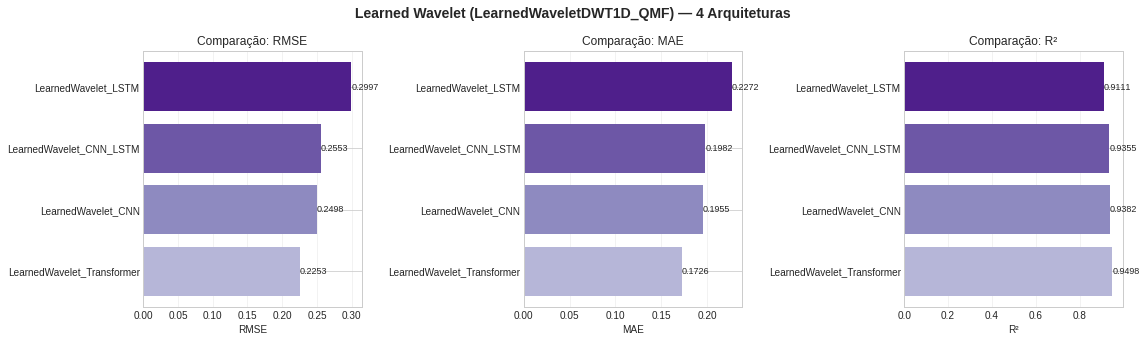

In [10]:
# Visualização comparativa
n_models = len(comparison_df)
fig, axes = plt.subplots(1, 3, figsize=(16, max(4, n_models * 1.2)))

metrics_to_plot = ['RMSE', 'MAE', 'R²']
colors = plt.cm.Purples(np.linspace(0.4, 0.9, n_models))

for idx, metric in enumerate(metrics_to_plot):
    data = comparison_df.set_index('Model')[metric].sort_values(
        ascending=(metric != 'R²')
    )
    bars = axes[idx].barh(data.index, data.values, color=colors[:len(data)])
    axes[idx].set_xlabel(metric)
    axes[idx].set_title(f'Comparação: {metric}')
    axes[idx].grid(True, alpha=0.3, axis='x')
    
    for bar, val in zip(bars, data.values):
        axes[idx].text(val, bar.get_y() + bar.get_height()/2,
                      f'{val:.4f}', va='center', ha='left', fontsize=9)

plt.suptitle('Learned Wavelet (LearnedWaveletDWT1D_QMF) — 4 Arquiteturas', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(RESULTS_DIR / "learned_wavelet_experiments" / "comparison_learned_wavelet.png", dpi=150, bbox_inches='tight')
plt.show()

## 9. Evolução do Treinamento

Visualização detalhada da evolução do processo de treinamento para cada arquitetura com Learned Wavelets:
- **Loss** (Train vs Validation) ao longo das épocas
- **Convergência** — velocidade e estabilidade
- **Early Stopping** — ponto de parada otimizado

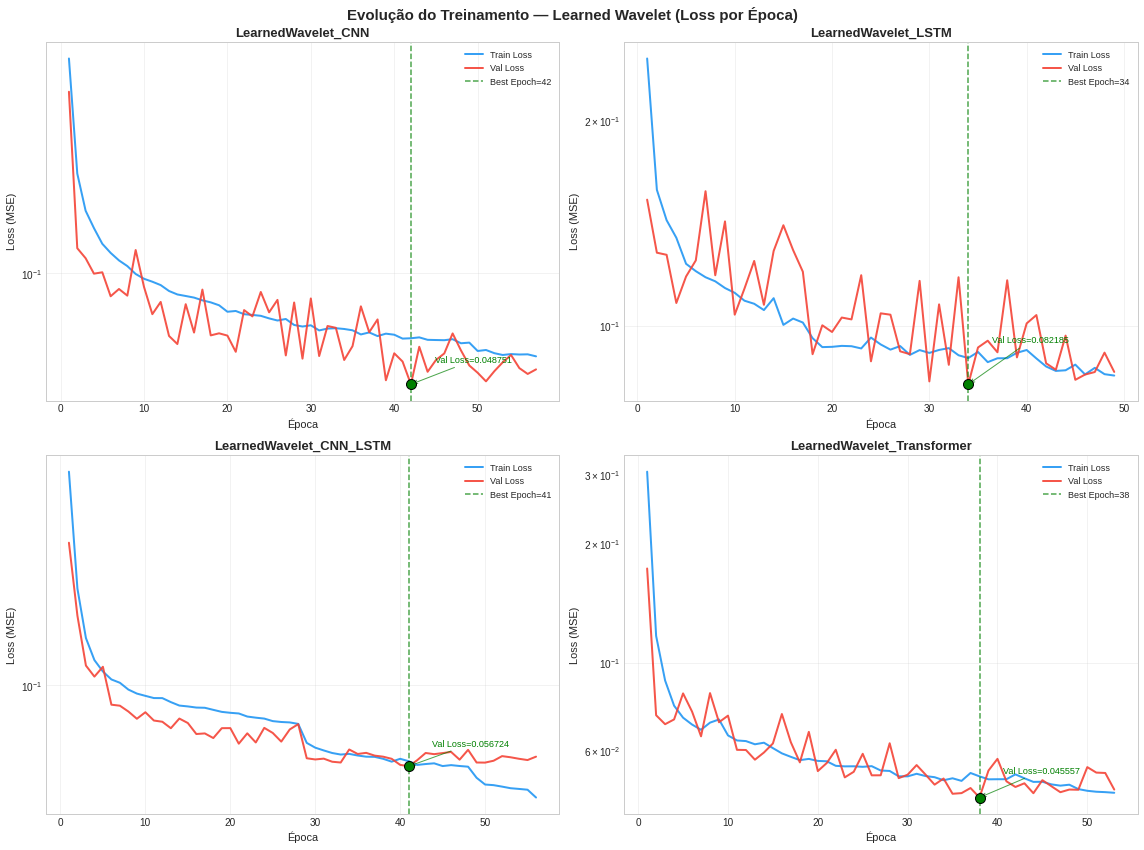

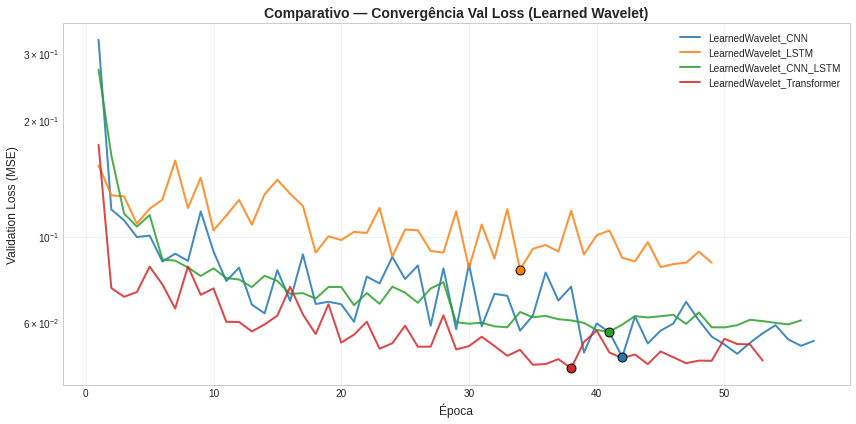


📊 Resumo da Evolução do Treinamento:
Modelo                          Épocas Train Loss Final  Val Loss Final  Best Val Loss  Best Epoch
----------------------------------------------------------------------------------------------------
LearnedWavelet_CNN                  57         0.058433        0.053700       0.048751          42
LearnedWavelet_LSTM                 49         0.084647        0.085693       0.082185          34
LearnedWavelet_CNN_LSTM             56         0.045581        0.060681       0.056724          41
LearnedWavelet_Transformer          53         0.046832        0.047718       0.045557          38


In [11]:
# ── Evolução do Treinamento: Loss (Train vs Val) por modelo ──
n_models = len(all_histories)
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

colors_lines = {'loss': '#2196F3', 'val_loss': '#F44336'}

for idx, (model_name, history) in enumerate(all_histories.items()):
    ax = axes[idx]
    epochs_range = range(1, len(history['loss']) + 1)
    
    # Train & Val loss
    ax.plot(epochs_range, history['loss'], color=colors_lines['loss'],
            linewidth=2, label='Train Loss', alpha=0.9)
    ax.plot(epochs_range, history['val_loss'], color=colors_lines['val_loss'],
            linewidth=2, label='Val Loss', alpha=0.9)
    
    # Marcar melhor época (menor val_loss)
    best_epoch = np.argmin(history['val_loss']) + 1
    best_val = min(history['val_loss'])
    ax.axvline(x=best_epoch, color='green', linestyle='--', alpha=0.7, label=f'Best Epoch={best_epoch}')
    ax.scatter([best_epoch], [best_val], color='green', s=100, zorder=5, edgecolors='black')
    
    # Anotação
    ax.annotate(f'Val Loss={best_val:.6f}',
                xy=(best_epoch, best_val),
                xytext=(best_epoch + len(epochs_range)*0.05, best_val * 1.15),
                fontsize=9, color='green',
                arrowprops=dict(arrowstyle='->', color='green', alpha=0.7))
    
    ax.set_xlabel('Época', fontsize=11)
    ax.set_ylabel('Loss (MSE)', fontsize=11)
    ax.set_title(f'{model_name}', fontsize=13, fontweight='bold')
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_yscale('log')

# Esconder subplots não usados
for idx in range(n_models, 4):
    axes[idx].set_visible(False)

plt.suptitle('Evolução do Treinamento — Learned Wavelet (Loss por Época)', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig(RESULTS_DIR / "learned_wavelet_experiments" / "training_evolution.png", dpi=150, bbox_inches='tight')
plt.show()

# ── Comparativo: todas as curvas de val_loss sobrepostas ──
fig, ax = plt.subplots(figsize=(12, 6))
cmap = plt.cm.tab10
for idx, (model_name, history) in enumerate(all_histories.items()):
    epochs_range = range(1, len(history['val_loss']) + 1)
    ax.plot(epochs_range, history['val_loss'], linewidth=2, label=model_name,
            color=cmap(idx), alpha=0.85)
    best_ep = np.argmin(history['val_loss']) + 1
    best_vl = min(history['val_loss'])
    ax.scatter([best_ep], [best_vl], color=cmap(idx), s=80, zorder=5, edgecolors='black')

ax.set_xlabel('Época', fontsize=12)
ax.set_ylabel('Validation Loss (MSE)', fontsize=12)
ax.set_title('Comparativo — Convergência Val Loss (Learned Wavelet)', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_yscale('log')
plt.tight_layout()
plt.savefig(RESULTS_DIR / "learned_wavelet_experiments" / "val_loss_comparison.png", dpi=150, bbox_inches='tight')
plt.show()

# ── Resumo numérico da evolução ──
print("\n📊 Resumo da Evolução do Treinamento:")
print(f"{'Modelo':<30} {'Épocas':>7} {'Train Loss Final':>16} {'Val Loss Final':>15} {'Best Val Loss':>14} {'Best Epoch':>11}")
print("-" * 100)
for model_name, history in all_histories.items():
    n_ep = len(history['loss'])
    best_ep = np.argmin(history['val_loss']) + 1
    print(f"{model_name:<30} {n_ep:>7} {history['loss'][-1]:>16.6f} {history['val_loss'][-1]:>15.6f} {min(history['val_loss']):>14.6f} {best_ep:>11}")

## 10. Visualização dos Filtros Aprendidos

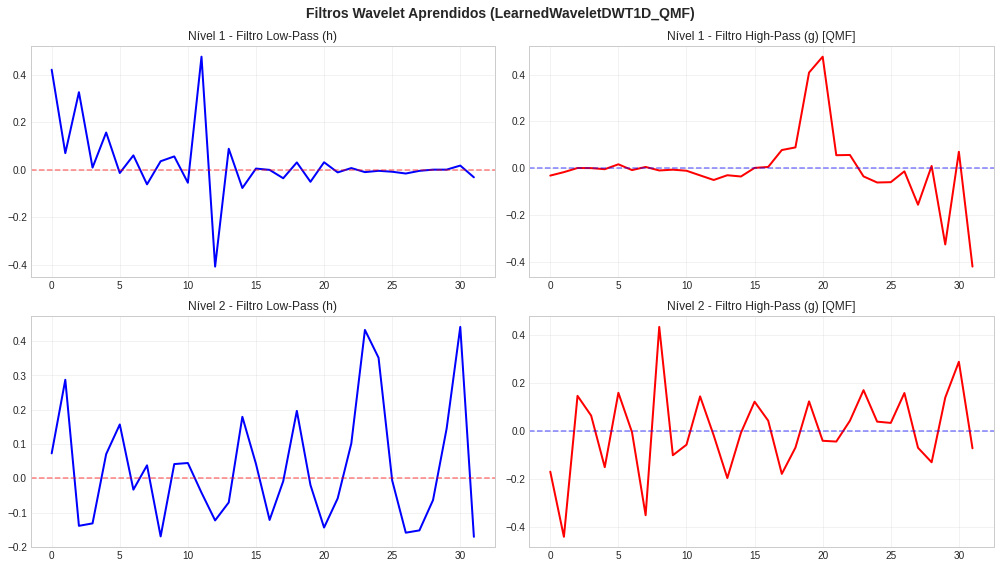


📊 Parâmetros dos Filtros Aprendidos:
  Nível 1: scale=0.7453, translation=-0.0005
  Nível 2: scale=0.3572, translation=0.1706


In [12]:
# Extrair e visualizar filtros aprendidos do melhor modelo CNN
def extract_learned_filters(model):
    """Extrai os filtros aprendidos da camada wavelet."""
    for layer in model.layers:
        if 'learned_wavelet' in layer.name.lower():
            pairs = layer.pairs
            filters_info = []
            for i, pair in enumerate(pairs):
                t = pair._make_t()
                scale = tf.nn.softplus(pair.raw_scale) + 1e-3
                t_adj = (t - pair.translation) / scale
                z = pair.base_net(t_adj)
                h = pair.low_head(z)
                h = pair._normalize_h(h)
                g = pair._qmf_from_h(h)
                filters_info.append({
                    'level': i + 1,
                    'low_pass': h.numpy().flatten(),
                    'high_pass': g.numpy().flatten(),
                    'scale': scale.numpy(),
                    'translation': pair.translation.numpy()
                })
            return filters_info
    return None

# Usar o melhor modelo CNN para visualização
ref_model = best_models.get('LearnedWavelet_CNN')
if ref_model is not None:
    filters = extract_learned_filters(ref_model)
    if filters:
        n_levels = len(filters)
        fig, axes = plt.subplots(n_levels, 2, figsize=(14, 4*n_levels))
        if n_levels == 1:
            axes = axes[np.newaxis, :]
        for i, filt in enumerate(filters):
            axes[i, 0].plot(filt['low_pass'], 'b-', linewidth=2)
            axes[i, 0].set_title(f'Nível {filt["level"]} - Filtro Low-Pass (h)')
            axes[i, 0].grid(True, alpha=0.3)
            axes[i, 0].axhline(y=0, color='r', linestyle='--', alpha=0.5)
            axes[i, 1].plot(filt['high_pass'], 'r-', linewidth=2)
            axes[i, 1].set_title(f'Nível {filt["level"]} - Filtro High-Pass (g) [QMF]')
            axes[i, 1].grid(True, alpha=0.3)
            axes[i, 1].axhline(y=0, color='b', linestyle='--', alpha=0.5)
        plt.suptitle('Filtros Wavelet Aprendidos (LearnedWaveletDWT1D_QMF)', fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.savefig(RESULTS_DIR / "learned_wavelet_experiments" / "learned_filters.png", dpi=150, bbox_inches='tight')
        plt.show()
        print("\n📊 Parâmetros dos Filtros Aprendidos:")
        for filt in filters:
            print(f"  Nível {filt['level']}: scale={filt['scale']:.4f}, translation={filt['translation']:.4f}")
else:
    print("⚠️ Nenhum modelo CNN best_model disponível para visualização de filtros")

## 11. Resumo

In [13]:
print("\n" + "="*70)
print("📋 RESUMO - Experimentos com Learned Wavelets")
print("="*70)
print(f"\n✅ Arquiteturas avaliadas: {len(comparison_df)} (CNN, LSTM, CNN-LSTM, Transformer)")
print(f"✅ Total de variações de grid testadas: {len(all_grid_results)}")
best_row = comparison_df.sort_values('RMSE').iloc[0]
print(f"✅ Melhor modelo: {best_row['Model']}")
print(f"✅ Melhor RMSE: {best_row['RMSE']:.6f}")
print(f"✅ Melhor R²: {best_row['R²']:.6f}")
print(f"\n📁 Resultados salvos em: {RESULTS_DIR / 'learned_wavelet_experiments'}")
print("\n🎉 Notebook concluído com sucesso!")


📋 RESUMO - Experimentos com Learned Wavelets

✅ Arquiteturas avaliadas: 4 (CNN, LSTM, CNN-LSTM, Transformer)
✅ Total de variações de grid testadas: 120
✅ Melhor modelo: LearnedWavelet_Transformer
✅ Melhor RMSE: 0.225296
✅ Melhor R²: 0.949773

📁 Resultados salvos em: /home/felipeteodoro/projetos/Doutorado/LearnableWaveletLayer/tests/synthetic/results/learned_wavelet_experiments

🎉 Notebook concluído com sucesso!
